In [3]:
import pandas as pd
import os
import langid
import json
from shapely.geometry import LineString
import geopandas as gpd
from shapely import wkt
import ast

os.chdir("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data")

## Reading and Cleaning

### Reviews

In [4]:
rev = pd.read_csv("reviews.csv")

In [5]:
rev = rev.drop_duplicates(subset = "review_id")

In [6]:
# Add time variables
rev['published_at_date'] = pd.to_datetime(rev['published_at_date'])

# Extract date and time (if needed)
rev['date'] = rev['published_at_date'].dt.date  # Extract just the date
rev['year'] = rev['published_at_date'].dt.year
rev['month'] = rev['published_at_date'].dt.month # Extract just the month
rev['weekday'] = rev['published_at_date'].dt.weekday

### Popular times

In [7]:
# Read data with info about locations and time
times = pd.read_csv("times.csv")
coordinates_places = times[["place_id", "coordinates"]]

# Parse the 'coordinates' column into separate latitude and longitude columns
times[['latitude', 'longitude']] = coordinates_places['coordinates'].apply(
    lambda x: pd.Series(json.loads(x))
)

# Drop the original 'coordinates' column for clarity
times = times.drop(columns='coordinates')

In [8]:
# add information about places where reviews are place and add geo info
crd = times[["place_id", "main_category", "latitude", "longitude"]]
rev = rev.merge(crd, how = "left", on = "place_id")

### Buurt

In [9]:
# Load the file with neighbourhood info
buurt = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/INDELING_BUURT (1).csv", delimiter=';')[["Buurt", "Wijk", "WKT_LNG_LAT"]]


# Load the points CSV
times_gdf = gpd.GeoDataFrame(
    times,
    geometry=gpd.points_from_xy(times['longitude'], times['latitude']),
    crs="EPSG:4326"  # Ensure the correct CRS, usually WGS84
)

# Load the polygons CSV
buurt['geometry'] = buurt['WKT_LNG_LAT'].apply(wkt.loads)
buurt_gdf = gpd.GeoDataFrame(buurt, geometry='geometry', crs="EPSG:4326")

# Perform spatial join
times_gdf = gpd.sjoin(times_gdf, buurt_gdf, how="left", predicate="within")
times_gdf = times_gdf.drop(columns = ["index_right", "WKT_LNG_LAT"])
times_gdf = times_gdf[["place_id", "Buurt", "Wijk"]]

In [10]:
rev = rev.merge(times_gdf, on = "place_id", how = "left")
rev

,place_id,place_name,review_id,reviewer_profile,published_at_date,total_number_of_reviews_by_reviewer,review_translated_text,date,year,month,weekday,main_category,latitude,longitude,Buurt,Wijk
0,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,ChZDSUhNMG9nS0VJQ0FnSUR2dFplN0hnEAE,https://www.google.com/maps/contrib/1172831811...,2024-12-25 14:46:56,45.0,"Excelente lugar y calido servicio, mi unica qu...",2024-12-25,2024.0,12.0,2.0,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West
1,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,ChZDSUhNMG9nS0VJQ0FnSUN2cmRxSERBEAE,https://www.google.com/maps/contrib/1130717941...,2024-12-18 14:46:56,1.0,NaN,2024-12-18,2024.0,12.0,2.0,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West
2,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,ChdDSUhNMG9nS0VJQ0FnSURQNmN6ejNRRRAB,https://www.google.com/maps/contrib/1145475064...,2024-12-08 14:46:56,1.0,"Zondag daar geweest,wel lekker gezeten maar sc...",2024-12-08,2024.0,12.0,6.0,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West
3,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,ChZDSUhNMG9nS0VJQ0FnSURQcG9xRUZnEAE,https://www.google.com/maps/contrib/1032501371...,2024-12-08 14:46:56,3.0,NaN,2024-12-08,2024.0,12.0,6.0,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West
4,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,ChdDSUhNMG9nS0VJQ0FnSURQMkpMcm5nRRAB,https://www.google.com/maps/contrib/1093401749...,2024-12-08 14:46:56,55.0,Food: 1/5 | Service: 5/5 | Atmosphere: 5/5,2024-12-08,2024.0,12.0,6.0,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4221245,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,ChZDSUhNMG9nS0VJQ0FnSURRczc3cVVBEAE,https://www.google.com/maps/contrib/1002552008...,2013-01-04 22:03:29,11.0,NaN,2013-01-04,2013.0,1.0,4.0,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten
4221246,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,ChdDSUhNMG9nS0VJQ0FnSUNRbUpQWHB3RRAB,https://www.google.com/maps/contrib/1104609722...,2013-01-04 22:03:29,1.0,"HABE DIE ZEIT DA GENOSSEN,UNVERGESLICH SCHON W...",2013-01-04,2013.0,1.0,4.0,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten
4221247,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,ChdDSUhNMG9nS0VJQ0FnSURBNzhxUHhRRRAB,https://www.google.com/maps/contrib/1084138238...,2013-01-04 22:03:29,12.0,NaN,2013-01-04,2013.0,1.0,4.0,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten
4221248,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,ChdDSUhNMG9nS0VJQ0FnSUNnd3IybjNRRRAB,https://www.google.com/maps/contrib/1118869897...,2013-01-04 22:03:30,58.0,NaN,2013-01-04,2013.0,1.0,4.0,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten


In [11]:
rev = rev[["place_id", "place_name", "reviewer_profile", "main_category", "latitude", "longitude", "Buurt", "Wijk", "year", "month"]]

In [12]:
reviews_per_year = rev.groupby('year').size().reset_index(name='count')
reviews_per_year

,year,count
0,2006.0,6
1,2008.0,2
2,2009.0,4
3,2010.0,11
4,2011.0,192
5,2012.0,862
6,2013.0,1623
7,2014.0,4140
8,2015.0,7028
9,2016.0,19283


In [13]:
review_counts = rev['reviewer_profile'].value_counts()

# Filter for profiles with more than one review
profiles_with_multiple_reviews = review_counts[review_counts > 1].index

# Filter the original dataframe to keep only profiles with multiple reviews
rev = rev[rev['reviewer_profile'].isin(profiles_with_multiple_reviews)]

In [14]:
kkkk = times[["place_id", "name"]]
kkkk

,place_id,name
0,ChIJFTdsYMMJxkcRryoUM7EyJY0,Nooch
1,ChIJz09EBcMJxkcRwRi15EQTPog,Restaurant de Struisvogel
2,ChIJIYdU8sMJxkcRD1Ys8SczZTE,Lotti's
3,ChIJMZGUGcMJxkcRPRyYTICSTYM,Restaurant 't Zwaantje
4,ChIJy3zD9cIJxkcRxfIlpjk47JQ,Bar Brasserie OCCO
...,...,...
7325,ChIJPcEtxHEKxkcRx84qVvhT_uE,Cityden Zuidas
7326,ChIJVWZIVwsKxkcR4vauw0vYxuk,"Holiday Inn Express Amsterdam - South, an IHG ..."
7327,ChIJC_KvV9jhxUcRgDzDAbDHkBw,Amsterdam Forest Hotel
7328,ChIJN8RMMqgLxkcRknxrSHEle1E,Aparthotel Adagio Amsterdam City South


In [14]:
cnt = rev[rev["year"] == 2024]
cnt = cnt["place_id"].value_counts().reset_index()
cnt = pd.DataFrame(cnt)
cnt = cnt.rename(columns = {"index":"place_id", "place_id":"reviews 2024"})
cnt["rev_prc"] = cnt["reviews 2024"]/cnt["reviews 2024"].max()
cnt = cnt.merge(kkkk, on = "place_id", how = "inner")
#cnt.to_csv("2024_count.csv", index = False)

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [15]:
rev['reviewer_profile'] = rev['reviewer_profile'].str.replace("https://www.google.com/maps/contrib/", "", regex=False)
rev['reviewer_profile'] = rev['reviewer_profile'].str.replace("/reviews?entry=ttu", "", regex=False)
rev

,place_id,place_name,reviewer_profile,main_category,latitude,longitude,Buurt,Wijk,year,month
0,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,117283181135164744824,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0
6,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,104924060214606889373,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0
8,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,105402032599514777278,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,11.0
9,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,110206659455840764563,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,11.0
10,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,105899618060142237470,Bar,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,11.0
...,...,...,...,...,...,...,...,...,...,...
4221235,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,101845634991245121042,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2014.0,1.0
4221241,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,114801359453973923048,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2014.0,1.0
4221245,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100255200870225431062,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2013.0,1.0
4221248,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,111886989762770868692,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2013.0,1.0


In [29]:
df = rev.merge(category, on = "place_id", how = "inner").drop(columns = {"main_category"})
df = df[df["category"] != "Hotel"]

In [30]:
df

,place_id,place_name,reviewer_profile,latitude,longitude,Buurt,Wijk,year,month,category
0,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,117283181135164744824,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,Dining & Cafes
1,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,104924060214606889373,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,Dining & Cafes
2,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,105402032599514777278,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,11.0,Dining & Cafes
3,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,110206659455840764563,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,11.0,Dining & Cafes
4,ChIJW_kWY7cJxkcR57gzEVWbFuw,Cafe de Geit,105899618060142237470,52.370336,4.886346,Felix Meritisbuurt,Grachtengordel-West,2024.0,11.0,Dining & Cafes
...,...,...,...,...,...,...,...,...,...,...
2685809,ChIJbRSbqjgKxkcRNRLe9cczdtU,De Riekermolen,110774298417841162395,52.324085,4.893780,Amstelpark,Buitenveldert-Oost,2017.0,1.0,Cultural & Historic
2685810,ChIJbRSbqjgKxkcRNRLe9cczdtU,De Riekermolen,115864948542815892636,52.324085,4.893780,Amstelpark,Buitenveldert-Oost,2017.0,1.0,Cultural & Historic
2685811,ChIJbRSbqjgKxkcRNRLe9cczdtU,De Riekermolen,103289039190481432054,52.324085,4.893780,Amstelpark,Buitenveldert-Oost,2017.0,1.0,Cultural & Historic
2685812,ChIJbRSbqjgKxkcRNRLe9cczdtU,De Riekermolen,102041274365038787043,52.324085,4.893780,Amstelpark,Buitenveldert-Oost,2016.0,1.0,Cultural & Historic


In [19]:
import pandas as pd
from collections import Counter
from itertools import tee

In [24]:
# 3. Define sliding window helper for n-grams
def sliding_window(iterable, n):
    """Generate n-length sliding windows over an iterable."""
    iterables = tee(iterable, n)
    for i, it in enumerate(iterables):
        for _ in range(i):
            next(it, None)
    return zip(*iterables)

# 4. Extract 2-step transitions (category_prev -> category_next)
records = []
for reviewer, group in df.groupby('reviewer_profile'):
    cats = group['category'].tolist()
    coords = list(zip(group['latitude'], group['longitude'], group['Buurt'], group['Wijk']))
    # iterate over pairs
    for (c1, c2), (_, info2) in zip(sliding_window(cats, 2), sliding_window(coords, 2)):
        lat2, lon2, buurt, wijk = info2
        records.append((c1, c2, lat2, lon2, buurt, wijk))

trans_df = pd.DataFrame(records, columns=[
    'cat_prev', 'cat_next', 'latitude', 'longitude', 'Buurt', 'Wijk'
])

# 5. Count most frequent category transitions
pair_counts = (
    trans_df
    .groupby(['cat_prev', 'cat_next'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print("Top 20 most frequent category transitions:")
print(pair_counts.head(20))

# 6. Spatial distribution for a given transition
# Example: pick the top transition
top_transition = pair_counts.iloc[0]
prev_cat, next_cat = top_transition['cat_prev'], top_transition['cat_next']

mask = (
    (trans_df['cat_prev'] == prev_cat) &
    (trans_df['cat_next'] == next_cat)
)
spatial_dist = (
    trans_df[mask]
    .groupby('Wijk')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print(f"Spatial distribution for transition {prev_cat} -> {next_cat} by district (Wijk):")
print(spatial_dist)

# 7. (Optional) Repeat for 3-step sequences
records3 = []
for reviewer, group in df.groupby('reviewer_profile'):
    cats = group['category'].tolist()
    for seq in sliding_window(cats, 3):
        records3.append(seq)

triple_counts = (
    pd.DataFrame(records3, columns=['cat1', 'cat2', 'cat3'])
    .groupby(['cat1', 'cat2', 'cat3'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print("Top 20 most frequent 3-category sequences:")
print(triple_counts.head(20))

Top 20 most frequent category transitions:
               cat_prev             cat_next   count
40       Dining & Cafes       Dining & Cafes  509307
30  Cultural & Historic  Cultural & Historic  263973
39       Dining & Cafes  Cultural & Historic  118882
31  Cultural & Historic       Dining & Cafes   94683
44       Dining & Cafes             Shopping   78197
34  Cultural & Historic     Green Recreation   45887
76             Shopping       Dining & Cafes   45531
80             Shopping             Shopping   43541
42       Dining & Cafes          Event venue   35271
10         Cannabisshop         Cannabisshop   33676
67     Green Recreation       Dining & Cafes   31722
58          Event venue       Dining & Cafes   31176
37       Dining & Cafes         Cannabisshop   24685
35  Cultural & Historic             Shopping   24317
13         Cannabisshop       Dining & Cafes   23596
33  Cultural & Historic          Event venue   23336
75             Shopping  Cultural & Historic   23293
70 

In [32]:
import pandas as pd
from itertools import combinations
from collections import Counter

# 1. Load your data
#    Change the filepath to wherever you keep your CSV/Parquet/etc.


# 2. Build each reviewer’s unique set of categories
baskets = (
    df[['reviewer_profile', 'category']]
      .drop_duplicates()                         # one category per user only
      .groupby('reviewer_profile')
      .category
      .apply(list)                               # list of categories per user
      .tolist()
)

# 3. Function to count top‐k combos of size n
def top_combinations(baskets, n, top_n=20):
    """
    baskets: list of lists of categories
    n: size of combination (2,3,4,5…)
    top_n: how many top results to return
    """
    cnt = Counter()
    for basket in baskets:
        # skip baskets smaller than n
        if len(basket) < n:
            continue
        # generate all combinations of size n (as sorted tuples)
        for combo in combinations(sorted(set(basket)), n):
            cnt[combo] += 1
    return cnt.most_common(top_n)

# Example: get the 10 most common pairs, triples, etc.
for size in [2,3,4,5]:
    print(f"\nTop 10 combos of size {size}:")
    for combo, freq in top_combinations(baskets, size, top_n=10):
        print(f"  {combo}: {freq:,}")

# 4. “For each category X, what combos (of size 2–5) including X are most common?”
def top_combos_for_category(baskets, focal, size, top_n=10):
    cnt = Counter()
    for basket in baskets:
        if focal not in basket or len(basket) < size:
            continue
        # take combinations of size `size` that include focal
        for combo in combinations(sorted(set(basket)), size):
            if focal in combo:
                cnt[combo] += 1
    return cnt.most_common(top_n)

categories = df['category'].unique()
results_by_category = {}
for cat in categories:
    results_by_category[cat] = {
        size: top_combos_for_category(baskets, cat, size, top_n=5)
        for size in [2,3,4,5]
    }

# You can then inspect, e.g.:
#import pprint
#pprint.pprint(results_by_category['Dining & Cafes'])



Top 10 combos of size 2:
  ('Cultural & Historic', 'Dining & Cafes'): 200,884
  ('Dining & Cafes', 'Shopping'): 90,578
  ('Cultural & Historic', 'Shopping'): 66,204
  ('Dining & Cafes', 'Green Recreation'): 64,860
  ('Dining & Cafes', 'Event venue'): 63,187
  ('Cultural & Historic', 'Green Recreation'): 57,412
  ('Cultural & Historic', 'Event venue'): 45,887
  ('Cannabisshop', 'Dining & Cafes'): 42,714
  ('Green Recreation', 'Shopping'): 31,923
  ('Event venue', 'Shopping'): 31,560

Top 10 combos of size 3:
  ('Cultural & Historic', 'Dining & Cafes', 'Shopping'): 46,587
  ('Cultural & Historic', 'Dining & Cafes', 'Green Recreation'): 40,567
  ('Cultural & Historic', 'Dining & Cafes', 'Event venue'): 32,407
  ('Dining & Cafes', 'Green Recreation', 'Shopping'): 25,792
  ('Dining & Cafes', 'Event venue', 'Shopping'): 24,035
  ('Cannabisshop', 'Cultural & Historic', 'Dining & Cafes'): 21,243
  ('Cultural & Historic', 'Green Recreation', 'Shopping'): 21,109
  ('Dining & Cafes', 'Event venu

In [34]:
def build_baskets(df):
    """
    Collapse to one row per (user,category), then build
    a list-of-lists: each reviewer_profile’s unique categories.
    """
    user_cat = df.drop_duplicates(subset=['reviewer_profile','category'])
    baskets = (
        user_cat
        .groupby('reviewer_profile')['category']
        .apply(list)
        .tolist()
    )
    return baskets

def count_combos_for_category(baskets, focal, combo_size, top_n=10):
    """
    Count how often combinations of size `combo_size` that include
    `focal` appear across all baskets.
    Returns a list of (combo_tuple, count), sorted descending.
    """
    cnt = Counter()
    for basket in baskets:
        if focal not in basket or len(basket) < combo_size:
            continue
        uniq = set(basket)
        for combo in combinations(sorted(uniq), combo_size):
            if focal in combo:
                cnt[combo] += 1
    return cnt.most_common(top_n)

def main(
    data_path='amsterdam_reviews.csv',
    sizes=(2,3,4,5),
    top_n=10,
    output_csv='category_combos.csv'
):
    # 1. Load & build baskets
    baskets = build_baskets(df)
    
    # 2. Iterate each category
    all_rows = []
    for cat in sorted(df['category'].unique()):
        for size in sizes:
            top = count_combos_for_category(baskets, cat, size, top_n=top_n)
            for combo, cnt in top:
                all_rows.append({
                    'category': cat,
                    'size': size,
                    'combo': combo,
                    'count': cnt
                })
    
    # 3. Build DataFrame & save
    result_df = pd.DataFrame(all_rows)
    result_df = result_df.sort_values(
        ['category','size','count'], 
        ascending=[True, True, False]
    )
    result_df.to_csv(output_csv, index=False)
    print(f"Saved top-{top_n} combos per category (sizes {sizes}) to {output_csv}")

if __name__ == '__main__':
    main()

Saved top-10 combos per category (sizes (2, 3, 4, 5)) to category_combos.csv


In [47]:
import matplotlib.pyplot as plt

Top 10 Tourist Activity Combinations
                           combo_str  count
Cultural & Historic + Dining & Cafes 200884
Cultural & Historic + Dining & Cafes 200884
           Dining & Cafes + Shopping  90578
           Dining & Cafes + Shopping  90578
      Cultural & Historic + Shopping  66204
      Cultural & Historic + Shopping  66204
   Dining & Cafes + Green Recreation  64860
   Dining & Cafes + Green Recreation  64860
        Dining & Cafes + Event venue  63187
        Dining & Cafes + Event venue  63187


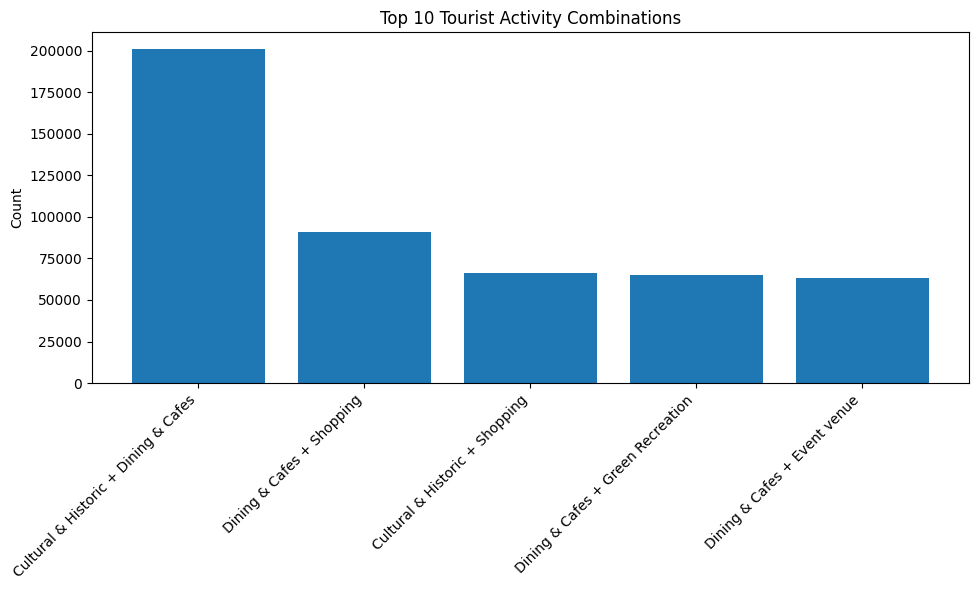

In [48]:
# Prepare combo strings
fr['combo_str'] = (
    fr['combo']
    .str.strip("()")
    .str.replace("'", "", regex=False)
    .str.replace(", ", " + ", regex=False)
)

# Extract top 10
top10 = fr.nlargest(10, 'count').reset_index(drop=True)

# Display table
print("Top 10 Tourist Activity Combinations")
print(top10[['combo_str', 'count']].to_string(index=False))

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(top10['combo_str'], top10['count'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Top 10 Tourist Activity Combinations')
plt.tight_layout()
plt.show()

In [38]:
from math import comb


def compute_self_combos(df, sizes=(2,3,4,5)):
    """
    For each (category, user), count distinct places, then summarize:
      - users_with_at_least_n: number of users who hit that threshold
      - total_self_combos: sum over users of C(k, n)
    Returns a DataFrame with columns:
      ['category','size','users_with_at_least_n','total_self_combos']
    """
    # 1) drop duplicates so each user–place counts only once
    df_unique = df.drop_duplicates(subset=['reviewer_profile','category','place_id'])
    
    # 2) count how many distinct places each user reviewed per category
    uc = (
        df_unique
        .groupby(['category','reviewer_profile'])
        .size()
        .reset_index(name='n_places')
    )
    
    # 3) for each category and each n, compute metrics
    records = []
    for cat, grp in uc.groupby('category'):
        for n in sizes:
            # how many users have >= n distinct places
            users_n = (grp['n_places'] >= n).sum()
            # total combinations of size n from each user’s k places
            combos_n = grp['n_places'].apply(lambda k: comb(k, n) if k >= n else 0).sum()
            records.append({
                'category': cat,
                'size': n,
                'users_with_at_least_n': users_n,
                'total_self_combos': combos_n
            })
    
    return pd.DataFrame.from_records(records)

def main(output_csv='self_category_combos.csv'):
    result_df = compute_self_combos(df, sizes=(2,3,4,5))
    # sort for readability
    result_df = result_df.sort_values(['category','size'])
    result_df.to_csv(output_csv, index=False)
    print(f"Results saved to {output_csv}")

if __name__ == '__main__':
    main()


Results saved to self_category_combos.csv


In [39]:
pd.read_csv("self_category_combos.csv")

,category,size,users_with_at_least_n,total_self_combos
0,Activities,2,7931,23172
1,Activities,3,2835,19286
2,Activities,4,1277,18121
3,Activities,5,577,16414
4,Cannabisshop,2,23154,120754
5,Cannabisshop,3,9698,317315
6,Cannabisshop,4,5077,1684741
7,Cannabisshop,5,2880,12945203
8,Conference,2,64,64
9,Conference,3,0,0


In [21]:
# 2. Handle missing trip information and cast types
# Drop rows without valid year or month
df = df.dropna(subset=['year', 'month'])
# Cast to integer now that NAs are removed
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)

# 3. Group reviews into 'trips' by reviewer + year + month
# All reviews in the same (reviewer, year, month) tuple count as one trip
groups = df.groupby(['reviewer_profile', 'year', 'month'])

# Helper: sliding window for sequences
def sliding_window(seq, n):
    """Generate n-length sliding windows over a sequence."""
    iterables = tee(seq, n)
    for i, it in enumerate(iterables):
        for _ in range(i):
            next(it, None)
    return zip(*iterables)

# 4. Extract 2-step transitions within each trip
two_step_records = []
for (_, _, _), trip in groups:
    cats = trip['category'].tolist()
    coords = list(zip(trip['latitude'], trip['longitude'], trip['Buurt'], trip['Wijk']))
    origin_buurt = trip.iloc[0]['Buurt']
    origin_wijk = trip.iloc[0]['Wijk']

    for (c1, c2), (_, info2) in zip(sliding_window(cats, 2), sliding_window(coords, 2)):
        lat2, lon2, buurt2, wijk2 = info2
        two_step_records.append({
            'cat_prev': c1,
            'cat_next': c2,
            'lat_next': lat2,
            'lon_next': lon2,
            'Buurt_prev': origin_buurt,
            'Buurt_next': buurt2,
            'Wijk_prev': origin_wijk,
            'Wijk_next': wijk2
        })

trans_df = pd.DataFrame(two_step_records)

# 5. Most frequent category transitions
top_pairs = (
    trans_df
    .groupby(['cat_prev', 'cat_next'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print("Top 20 category transitions:")
print(top_pairs.head(20))

# 6. Origin–Destination flows between neighbourhoods
od_flows = (
    trans_df
    .groupby(['Buurt_prev', 'Buurt_next'])
    .size()
    .reset_index(name='flow_count')
    .sort_values('flow_count', ascending=False)
)
print("Top 20 neighbourhood origin–destination flows:")
print(od_flows.head(20))
# 8. Optional: Extract 3-step sequences for Sankey/alluvial diagrams
seq3 = []
for (_, _, _), trip in groups:
    cats = trip['category'].tolist()
    for c1, c2, c3 in sliding_window(cats, 3):
        seq3.append((c1, c2, c3))

seq3_counts = (
    pd.DataFrame(seq3, columns=['cat1', 'cat2', 'cat3'])
    .groupby(['cat1', 'cat2', 'cat3'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print("Top 20 3-category sequences:")
print(seq3_counts.head(20))

Top 20 category transitions:
               cat_prev             cat_next   count
44       Dining & Cafes       Dining & Cafes  362629
33  Cultural & Historic  Cultural & Historic  229257
43       Dining & Cafes  Cultural & Historic  108070
34  Cultural & Historic       Dining & Cafes   72421
38  Cultural & Historic                Hotel   71933
48       Dining & Cafes                Hotel   60992
84                Hotel       Dining & Cafes   58960
49       Dining & Cafes             Shopping   56495
37  Cultural & Historic     Green Recreation   39583
94             Shopping       Dining & Cafes   32219
99             Shopping             Shopping   29478
46       Dining & Cafes          Event venue   27786
11         Cannabisshop         Cannabisshop   27118
74     Green Recreation       Dining & Cafes   23198
88                Hotel                Hotel   21511
64          Event venue       Dining & Cafes   20354
41       Dining & Cafes         Cannabisshop   19727
39  Cultural & Hi

In [35]:
od_flows

,Buurt_prev,Buurt_next,flow_count
23758,Leliegracht e.o.,Museumplein,13903
26524,Museumplein,Museumplein,13731
23762,Leliegracht e.o.,Nieuwe Kerk e.o.,7366
18812,Hoofdcentrum-Zuidoost,Hoofdcentrum-Zuidoost,7306
26528,Museumplein,Nieuwe Kerk e.o.,6523
...,...,...,...
47014,Zuidwestkwadrant-Zuid,Venserpolder-West,1
19,AMC,Hemknoop-Noord,1
18,AMC,Helmersbuurt-Oost,1
17,AMC,Haarlemmerbuurt-West,1


In [16]:
hotels = rev[rev["main_category"] == "Hotel"]
visit = rev[rev["main_category"] != "Hotel"]

In [17]:
hotre = hotels.groupby("year").size().reset_index(name="count")

In [18]:
move = hotels.merge(visit, on = ["reviewer_profile", "year", "month"], how = "inner", suffixes=('_hotel', '_visited'))
move

,place_id_hotel,place_name_hotel,reviewer_profile,main_category_hotel,latitude_hotel,longitude_hotel,Buurt_hotel,Wijk_hotel,year,month,place_id_visited,place_name_visited,main_category_visited,latitude_visited,longitude_visited,Buurt_visited,Wijk_visited
0,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,113987166664752762552,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJKYyxKekJxkcRLAhtiEY8skw,Paradiso,Locatie voor live muziek,52.362162,4.883806,Leidsebuurt-Zuidoost,De Weteringschans
1,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,111451103947221399197,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJg8bf-sIJxkcR9mc7li6y48E,Restaurant Vinkeles,Haute-cuisinerestaurant,52.369279,4.884023,Felix Meritisbuurt,Grachtengordel-West
2,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103465487052100699800,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJg8bf-sIJxkcR9mc7li6y48E,Restaurant Vinkeles,Haute-cuisinerestaurant,52.369279,4.884023,Felix Meritisbuurt,Grachtengordel-West
3,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103696723483599084456,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJd_yDtNAJxkcRko3UnBeygWA,Chun Cafe Berenstraat,Broodjeswinkel,52.370469,4.883942,Felix Meritisbuurt,Grachtengordel-West
4,ChIJg8bf-sIJxkcRsvcYZBHfZ14,The Dylan Amsterdam,103696723483599084456,Hotel,52.369359,4.884211,Felix Meritisbuurt,Grachtengordel-West,2024.0,12.0,ChIJrftMriIJxkcRmsYdm9XycFA,Fabel Friet Runstraat,Snackbar,52.368827,4.884062,Leidsegracht-Noord,Grachtengordel-West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881551,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJX1rTlu8JxkcRGsV8-a4oKMI,Van Gogh Museum,Kunstmuseum,52.358076,4.881205,Museumplein,Museumkwartier
881552,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJKzDpZ-UJxkcR6tvKHK2aPOw,Stedelijk Museum Amsterdam,Kunstmuseum,52.358011,4.879755,Museumplein,Museumkwartier
881553,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,100760819610118435434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2016.0,1.0,ChIJs-qtwfwJxkcR4-6lQTbCXw0,Brasserie Van Dam,Brasserie,52.355639,4.870725,Cornelis Schuytbuurt,Museumkwartier
881554,ChIJzVN3QY_hxUcREIzfWnT4u94,Hotel Artemis Amsterdam,110491801846102150434,Hotel,52.341766,4.824797,Riekerpolder,Sloten/Nieuw-Sloten,2014.0,1.0,ChIJS4P1Hb4JxkcRIphGLOfikzU,Xtracold Icebar Amsterdam,Bar,52.366458,4.900025,Rembrandtplein e.o.,Grachtengordel-Zuid


In [19]:
movement_from_hotel = move
movement_from_hotel = movement_from_hotel[["place_id_hotel", "place_name_hotel", "main_category_visited", "latitude_visited", "longitude_visited"]]
#movement_from_hotel.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/movement_from_hotel.csv", index = False)

In [17]:
category = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/places_categorised.csv", index_col = 0)[["place_id", "category"]]
category

,place_id,category
0,ChIJ5Ra7we4JxkcRhYVAaq5zQ9U,Cultural & Historic
1,ChIJX1rTlu8JxkcRGsV8-a4oKMI,Cultural & Historic
2,ChIJSRE-IcUJxkcRCltjPmVdmtQ,Cultural & Historic
3,ChIJz3y0xeIJxkcRNcogBVV41Gw,Green Recreation
4,ChIJFQ6IwMYJxkcRis8dtZlOkTk,Cultural & Historic
...,...,...
3415,ChIJDTJApHYJxkcRhG9hc0IeAwE,Dining & Cafes
3416,ChIJXfPyb9EJxkcRs-16etxpLFA,Cannabisshop
3417,ChIJw8rNvJ0JxkcRyiZjcbys2bs,Cultural & Historic
3418,ChIJ3zWdMVnixUcR78oyUEcmf6c,Dining & Cafes


In [21]:
move_category = move.merge(category, left_on = "place_id_visited", right_on = "place_id", how = "inner")

In [22]:
user_visits = move_category.groupby(['reviewer_profile', 'year', 'month'])['category'].apply(list).reset_index()


### Sequence

In [23]:
category_count = user_visits["category"].value_counts().reset_index()

# Example: your DataFrame is named `category_count`
def normalize_category(x):
    # Only parse with ast.literal_eval if it's a string
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return tuple(sorted(x))

# Normalize the category column
category_count['normalized_category'] = category_count['category'].apply(normalize_category)

# Group by the normalized category and sum the counts
grouped_df = category_count.groupby('normalized_category', as_index=False)['count'].sum()

# Optional: convert back to list format for readability
grouped_df['category'] = grouped_df['normalized_category'].apply(lambda x: str(list(x)))

# Drop helper column if you like
grouped_df = grouped_df.drop(columns='normalized_category')

In [24]:
grouped_df.sort_values("count", ascending = False).head(5)

,count,category
11560,31570,['Dining & Cafes']
7776,20636,['Cultural & Historic']
11561,10450,"['Dining & Cafes', 'Dining & Cafes']"
10947,9097,"['Cultural & Historic', 'Dining & Cafes']"
7777,6979,"['Cultural & Historic', 'Cultural & Historic']"


### Buurt sequence

In [23]:
user_visits_buurt = user_visits.merge(move[["reviewer_profile", "year", "month", "Buurt_hotel"]], 
                                      on = ["reviewer_profile", "year", "month"], 
                                      how = "inner").drop_duplicates(["reviewer_profile", "year", "month"])

In [24]:
def normalize_category(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return tuple(sorted(x))

# Apply this function before grouping
user_visits_buurt["normalized_category"] = user_visits_buurt["category"].apply(normalize_category)

# Now you can group by the buurt and normalized category
category_count_buurt = user_visits_buurt.groupby(["Buurt_hotel", "normalized_category"]).size().reset_index(name="count")

# Optional: make category more readable
category_count_buurt["category"] = category_count_buurt["normalized_category"].apply(lambda x: str(list(x)))

# Drop the tuple column if you want
category_count_buurt = category_count_buurt.drop(columns=["normalized_category"])
category_count_buurt.sort_values("count", ascending = False)

,Buurt_hotel,count,category
36025,Sloterdijk Stationskwartier,1573,['Dining & Cafes']
35584,Sloterdijk Stationskwartier,1258,['Cultural & Historic']
40952,Vondelparkbuurt-Oost,1109,['Dining & Cafes']
29174,Oude Kerk e.o.,1039,['Dining & Cafes']
700,Amstel III deel A/B-Noord,1008,['Dining & Cafes']
...,...,...,...
20,Amstel III deel A/B-Noord,1,"['Activities', 'Activities', 'Cannabisshop', '..."
19,Amstel III deel A/B-Noord,1,"['Activities', 'Activities', 'Cannabisshop', '..."
18,Amstel III deel A/B-Noord,1,"['Activities', 'Activities', 'Cannabisshop', '..."
17,Amstel III deel A/B-Noord,1,"['Activities', 'Activities', 'Activities', 'Ev..."


In [25]:
bijlmer_arena = ["Hoofdcentrum-Zuidoost", "Amstel III deel A/B-Noord", "Amsterdamse Poort"]
zuidas = ["Beatrixpark", "Zuidas-Noord", "RAI", "Zuidas-Zuid", "Vivaldi", "De Klenckebuurt"]
sloterdijk = ["Sloterdijk Stationskwartier"]

In [26]:
zuidas_core = category_count_buurt[category_count_buurt["Buurt_hotel"].isin(zuidas)]
zuidas_core = zuidas_core.groupby("category")[["count"]].sum().reset_index()
zuidas_core["count_sum"] = zuidas_core["count"].sum()
zuidas_core["percentage"] = zuidas_core["count"]/zuidas_core["count_sum"]*100
zuidas_core.sort_values("percentage", ascending = False).head(10)

,category,count,count_sum,percentage
779,['Dining & Cafes'],984,5065,19.427443
659,['Cultural & Historic'],469,5065,9.259625
754,"['Dining & Cafes', 'Dining & Cafes']",314,5065,6.199408
644,"['Cultural & Historic', 'Dining & Cafes']",204,5065,4.027641
386,['Conference'],187,5065,3.692004
581,"['Cultural & Historic', 'Cultural & Historic']",146,5065,2.882527
809,['Shopping'],138,5065,2.724580
795,['Event venue'],104,5065,2.053307
803,['Green Recreation'],92,5065,1.816387
371,"['Conference', 'Dining & Cafes']",90,5065,1.776900


In [27]:
bijlmer_arena_core = category_count_buurt[category_count_buurt["Buurt_hotel"].isin(bijlmer_arena)]
bijlmer_arena_core = bijlmer_arena_core.groupby("category")[["count"]].sum().reset_index()
bijlmer_arena_core["count_sum"] = bijlmer_arena_core["count"].sum()
bijlmer_arena_core["percentage"] = bijlmer_arena_core["count"]/bijlmer_arena_core["count_sum"]*100
bijlmer_arena_core.sort_values("percentage", ascending = False).head(10)

,category,count,count_sum,percentage
1282,['Dining & Cafes'],1592,10042,15.853416
1313,['Event venue'],888,10042,8.842860
1074,['Cultural & Historic'],868,10042,8.643696
1251,"['Dining & Cafes', 'Dining & Cafes']",471,10042,4.690301
1052,"['Cultural & Historic', 'Dining & Cafes']",377,10042,3.754232
1270,"['Dining & Cafes', 'Event venue']",277,10042,2.758415
965,"['Cultural & Historic', 'Cultural & Historic']",256,10042,2.549293
1327,['Shopping'],252,10042,2.509460
1029,"['Cultural & Historic', 'Dining & Cafes', 'Din...",157,10042,1.563434
500,['Cannabisshop'],141,10042,1.404103


In [28]:
sloterdijk_core = category_count_buurt[category_count_buurt["Buurt_hotel"].isin(sloterdijk)]
sloterdijk_core = sloterdijk_core.groupby("category")[["count"]].sum().reset_index()
sloterdijk_core["count_sum"] = sloterdijk_core["count"].sum()
sloterdijk_core["percentage"] = sloterdijk_core["count"]/sloterdijk_core["count_sum"]*100
sloterdijk_core.sort_values("percentage", ascending = False).head(20)

,category,count,count_sum,percentage
1100,['Dining & Cafes'],1573,9442,16.659606
990,['Cultural & Historic'],1258,9442,13.323448
972,"['Cultural & Historic', 'Dining & Cafes']",500,9442,5.295488
898,"['Cultural & Historic', 'Cultural & Historic']",441,9442,4.670621
1077,"['Dining & Cafes', 'Dining & Cafes']",414,9442,4.384664
877,"['Cultural & Historic', 'Cultural & Historic',...",223,9442,2.361788
483,['Cannabisshop'],213,9442,2.255878
948,"['Cultural & Historic', 'Dining & Cafes', 'Din...",184,9442,1.948740
1137,['Shopping'],172,9442,1.821648
1116,['Event venue'],142,9442,1.503919


In [31]:
category_count_buurt_filtered = category_count_buurt[category_count_buurt['category'].apply(lambda x: len(set(x)) > 1)]
category_count_buurt_filtered

,Buurt_hotel,count,category
0,Amstel III deel A/B-Noord,9,['Activities']
1,Amstel III deel A/B-Noord,2,"['Activities', 'Activities']"
2,Amstel III deel A/B-Noord,1,"['Activities', 'Activities', 'Activities', 'Ac..."
3,Amstel III deel A/B-Noord,1,"['Activities', 'Activities', 'Activities', 'Ac..."
4,Amstel III deel A/B-Noord,1,"['Activities', 'Activities', 'Activities', 'Ac..."
...,...,...,...
44935,Zuiderkerkbuurt,5,['Hotel']
44936,Zuiderkerkbuurt,1,"['Hotel', 'Hotel']"
44937,Zuiderkerkbuurt,1,"['Hotel', 'Hotel', 'Hotel']"
44938,Zuiderkerkbuurt,14,['Shopping']


In [33]:
category_count_buurt_list = category_count_buurt

# If 'category' is a string, first convert it to an actual list
category_count_buurt_list['category'] = category_count_buurt_list['category'].apply(ast.literal_eval)

# Now filter out rows where there's only one unique category
category_count_buurt_filtered = category_count_buurt_list[category_count_buurt_list['category'].apply(lambda x: len(set(x)) > 1)]

# Optional: Reset index if you want
category_count_buurt_filtered = category_count_buurt_filtered.reset_index(drop=True)

In [34]:
category_count_buurt_filtered

,Buurt_hotel,count,category
0,Amstel III deel A/B-Noord,1,"[Activities, Activities, Activities, Activitie..."
1,Amstel III deel A/B-Noord,1,"[Activities, Activities, Activities, Activitie..."
2,Amstel III deel A/B-Noord,1,"[Activities, Activities, Activities, Activitie..."
3,Amstel III deel A/B-Noord,1,"[Activities, Activities, Activities, Activitie..."
4,Amstel III deel A/B-Noord,1,"[Activities, Activities, Activities, Activitie..."
...,...,...,...
41005,Zuiderkerkbuurt,4,"[Dining & Cafes, Green Recreation]"
41006,Zuiderkerkbuurt,1,"[Dining & Cafes, Green Recreation, Shopping]"
41007,Zuiderkerkbuurt,8,"[Dining & Cafes, Shopping]"
41008,Zuiderkerkbuurt,1,"[Green Recreation, Green Recreation, Shopping]"


In [47]:
sloterdijk_core = category_count_buurt_filtered[category_count_buurt_filtered["Buurt_hotel"].isin(sloterdijk)]
sloterdijk_core["category"] = sloterdijk_core["category"].apply(lambda x: str(list(x)))
sloterdijk_core = sloterdijk_core.groupby("category")[["count"]].sum().reset_index()
sloterdijk_core["count_sum"] = sloterdijk_core["count"].sum()
sloterdijk_core["percentage"] = sloterdijk_core["count"]/sloterdijk_core["count_sum"]*100
#sloterdijk_core.sort_values("percentage", ascending = False)
sloterdijk_core["core"] = "sloterdijk"

C:\Users\isamu\AppData\Local\Temp\ipykernel_5812\1529334961.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sloterdijk_core["category"] = sloterdijk_core["category"].apply(lambda x: str(list(x)))


In [48]:
zuidas_core = category_count_buurt_filtered[category_count_buurt_filtered["Buurt_hotel"].isin(zuidas)]
zuidas_core["category"] = zuidas_core["category"].apply(lambda x: str(list(x)))
zuidas_core = zuidas_core.groupby("category")[["count"]].sum().reset_index()
zuidas_core["count_sum"] = zuidas_core["count"].sum()
zuidas_core["percentage"] = zuidas_core["count"]/zuidas_core["count_sum"]*100
#zuidas_core.sort_values("percentage", ascending = False).head(10)
zuidas_core["core"] = "zuidas"

C:\Users\isamu\AppData\Local\Temp\ipykernel_5812\930498265.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zuidas_core["category"] = zuidas_core["category"].apply(lambda x: str(list(x)))


In [49]:
bijlmer_arena_core = category_count_buurt_filtered[category_count_buurt_filtered["Buurt_hotel"].isin(bijlmer_arena)]
bijlmer_arena_core["category"] = bijlmer_arena_core["category"].apply(lambda x: str(list(x)))
bijlmer_arena_core = bijlmer_arena_core.groupby("category")[["count"]].sum().reset_index()
bijlmer_arena_core["count_sum"] = bijlmer_arena_core["count"].sum()
bijlmer_arena_core["percentage"] = bijlmer_arena_core["count"]/bijlmer_arena_core["count_sum"]*100
#bijlmer_arena_core.sort_values("percentage", ascending = False).head(10)
bijlmer_arena_core["core"] = "bijlmer arena"

C:\Users\isamu\AppData\Local\Temp\ipykernel_5812\82199773.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bijlmer_arena_core["category"] = bijlmer_arena_core["category"].apply(lambda x: str(list(x)))


In [51]:
sequence_cores = pd.concat([sloterdijk_core, zuidas_core, bijlmer_arena_core])

In [52]:
sequence_cores.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/sequence_cores.csv")